In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training images shape : {x_train.shape}")
print(f"Test images shape     : {x_test.shape}")
print(f"Training labels shape : {y_train.shape}")
print(f"Pixel value range     : [{x_train.min()}, {x_train.max()}]")
print(f"Number of classes     : {len(class_names)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step
Training images shape : (50000, 32, 32, 3)
Test images shape     : (10000, 32, 32, 3)
Training labels shape : (50000, 1)
Pixel value range     : [0, 255]
Number of classes     : 10


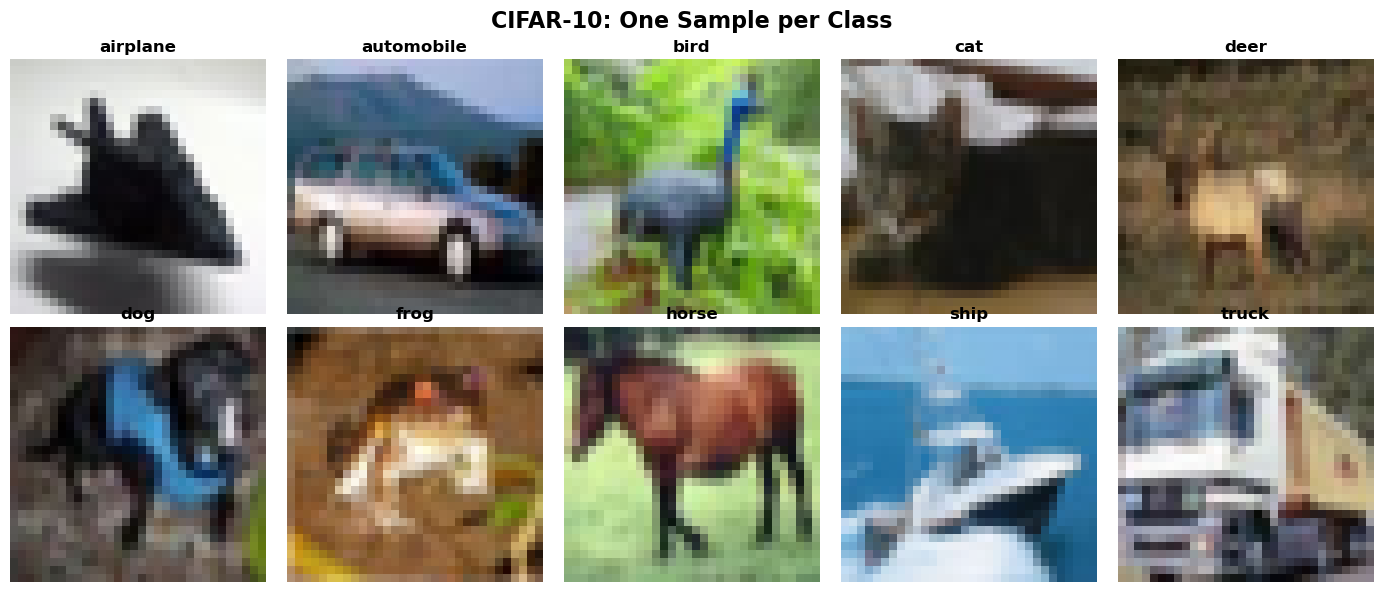


Class Distribution in Training Set:
  airplane    : 5000 images
  automobile  : 5000 images
  bird        : 5000 images
  cat         : 5000 images
  deer        : 5000 images
  dog         : 5000 images
  frog        : 5000 images
  horse       : 5000 images
  ship        : 5000 images
  truck       : 5000 images


In [ ]:
# Display one image per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CIFAR-10: One Sample per Class', fontsize=16, fontweight='bold')

for class_idx in range(10):
    # Find first occurrence of this class
    idx = np.where(y_train.flatten() == class_idx)[0][0]
    ax = axes[class_idx // 5][class_idx % 5]
    ax.imshow(x_train[idx])
    ax.set_title(class_names[class_idx], fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Show class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("\nClass Distribution in Training Set:")
for cls, cnt in zip(class_names, counts):
    print(f"  {cls:12s}: {cnt} images")

In [ ]:
# Normalize pixel values: 0-255 → 0.0-1.0
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Flatten for ANN (32*32*3 = 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("For CNN  — x_train_norm shape :", x_train_norm.shape)
print("For ANN  — x_train_flat shape :", x_train_flat.shape)
print(f"Normalized pixel range: [{x_train_norm.min():.1f}, {x_train_norm.max():.1f}]")

For CNN  — x_train_norm shape : (50000, 32, 32, 3)
For ANN  — x_train_flat shape : (50000, 3072)
Normalized pixel range: [0.0, 1.0]


In [ ]:
# ── ANN Model Definition ──────────────────────────────────────────
ann_model = models.Sequential([
    # Input layer (flattened image: 32*32*3 = 3072)
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),        # Regularization: randomly disables 30% neurons

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    # Output layer: 10 neurons (one per class), softmax gives probabilities
    layers.Dense(10, activation='softmax')
], name='ANN_Model')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train ANN ────────────────────────────────────────────────────
# EarlyStopping: stops training if val_loss doesn't improve for 3 epochs
early_stop_ann = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training ANN model...")
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,                  # Allow up to 20 epochs
    validation_split=0.1,       # 10% of train data used for validation
    batch_size=64,
    callbacks=[early_stop_ann],
    verbose=1
)

Training ANN model...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.2462 - loss: 2.0313 - val_accuracy: 0.3228 - val_loss: 1.8960
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.2924 - loss: 1.9090 - val_accuracy: 0.3388 - val_loss: 1.8316
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3150 - loss: 1.8609 - val_accuracy: 0.3296 - val_loss: 1.8400
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3262 - loss: 1.8360 - val_accuracy: 0.3734 - val_loss: 1.7757
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3413 - loss: 1.8050 - val_accuracy: 0.3752 - val_loss: 1.7568
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3461 - loss: 1.7925 - val_accuracy: 0.3844 - val_loss: 1.7409
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3504 - loss: 1.7752 - val_accuracy: 0.3818 - val_loss: 1.7459
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.36

In [ ]:
# ── Evaluate ANN ─────────────────────────────────────────────────
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"ANN Test Loss     : {ann_test_loss:.4f}")
print(f"ANN Test Accuracy : {ann_test_acc*100:.2f}%")
print(f"{'='*40}")


ANN Test Loss     : 1.6328
ANN Test Accuracy : 42.19%


In [ ]:
# ── CNN Model Definition ──────────────────────────────────────────
cnn_model = models.Sequential([
    # Block 1: Detect edges & low-level features
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),     # Normalize activations → faster + stable training
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),      # Halve spatial dims: 32x32 → 16x16
    layers.Dropout(0.25),

    # Block 2: Detect shapes & textures
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),      # 16x16 → 8x8
    layers.Dropout(0.25),

    # Block 3: Detect high-level patterns
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),      # 8x8 → 4x4
    layers.Dropout(0.25),

    # Classifier head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN_Model')

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,458 (2.55 MB)

 Trainable params: 667,498 (2.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ── Train CNN ────────────────────────────────────────────────────
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

print("Training CNN model...")
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_cnn, reduce_lr],
    verbose=1
)

Training CNN model...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 83ms/step - accuracy: 0.4332 - loss: 1.6909 - val_accuracy: 0.4378 - val_loss: 1.6368 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.5976 - loss: 1.1271 - val_accuracy: 0.6330 - val_loss: 1.0499 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.6650 - loss: 0.9470 - val_accuracy: 0.6952 - val_loss: 0.8713 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.7030 - loss: 0.8499 - val_accuracy: 0.7186 - val_loss: 0.8150 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.7262 - loss: 0.7832 - val_accuracy: 0.7082 - val_loss: 0.8895 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.7455 - loss: 0.7313 - val_accuracy: 0.7754 - val_loss: 0.6613 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step 

In [ ]:
# ── Evaluate CNN ─────────────────────────────────────────────────
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"CNN Test Loss     : {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy : {cnn_test_acc*100:.2f}%")
print(f"{'='*40}")


CNN Test Loss     : 0.4968
CNN Test Accuracy : 83.39%


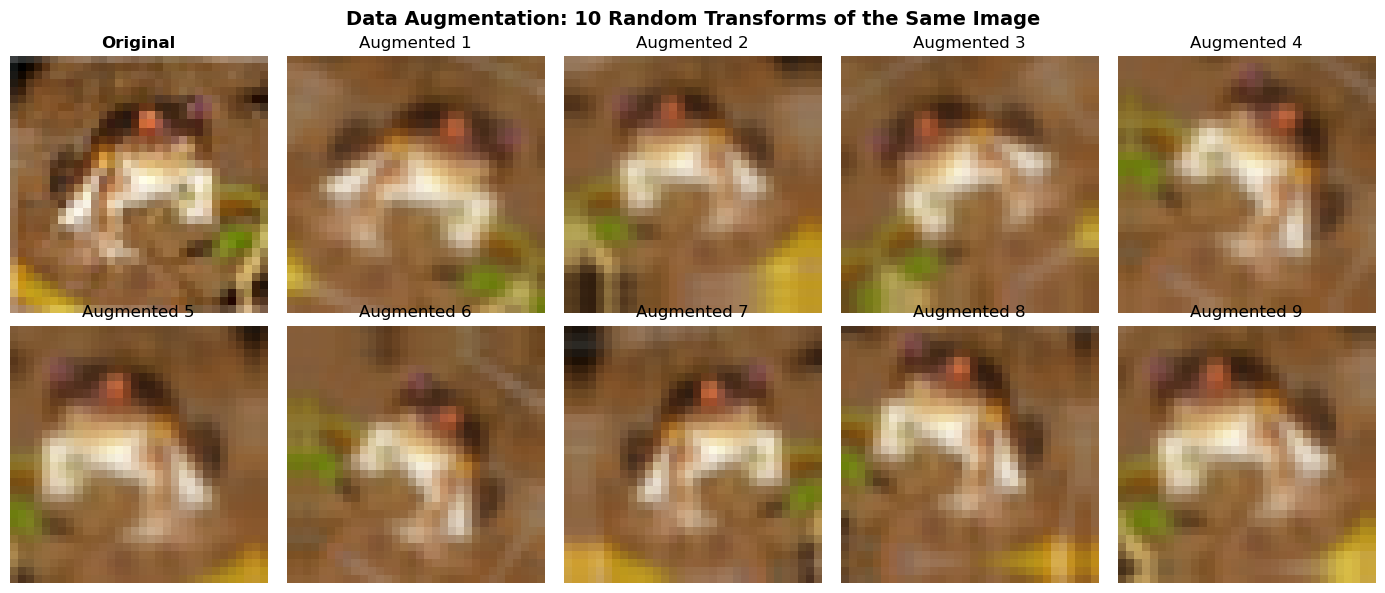

In [ ]:
# ── Visualize Augmentations ───────────────────────────────────────
augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

sample_image = x_train_norm[0:1]  # Take one image (keep batch dim)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Data Augmentation: 10 Random Transforms of the Same Image',
             fontsize=14, fontweight='bold')

axes[0][0].imshow(sample_image[0])
axes[0][0].set_title('Original', fontweight='bold')
axes[0][0].axis('off')

for i in range(1, 10):
    aug_img = augmentation_layer(sample_image, training=True)
    r, c = i // 5, i % 5
    axes[r][c].imshow(aug_img[0])
    axes[r][c].set_title(f'Augmented {i}')
    axes[r][c].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ── CNN + Augmentation Model ──────────────────────────────────────
aug_cnn_model = models.Sequential([
    # Augmentation (only active during training)
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN_Augmented_Model')

aug_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "CNN_Augmented_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train CNN + Augmentation ──────────────────────────────────────
early_stop_aug = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_aug = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

print("Training CNN + Augmentation model...")
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug, reduce_lr_aug],
    verbose=1
)

Training CNN + Augmentation model...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 75ms/step - accuracy: 0.3648 - loss: 1.8633 - val_accuracy: 0.3940 - val_loss: 1.7889 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.4727 - loss: 1.4622 - val_accuracy: 0.4466 - val_loss: 1.6243 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.5218 - loss: 1.3304 - val_accuracy: 0.5638 - val_loss: 1.2220 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.5583 - loss: 1.2353 - val_accuracy: 0.5874 - val_loss: 1.2272 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.5848 - loss: 1.1747 - val_accuracy: 0.5368 - val_loss: 1.4048 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.6043 - loss: 1.1178 - val_accuracy: 0.6238 - val_loss: 1.1156 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# ── Evaluate CNN + Augmentation ───────────────────────────────────
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"CNN+Aug Test Loss     : {aug_test_loss:.4f}")
print(f"CNN+Aug Test Accuracy : {aug_test_acc*100:.2f}%")
print(f"{'='*40}")


CNN+Aug Test Loss     : 0.7443
CNN+Aug Test Accuracy : 74.58%


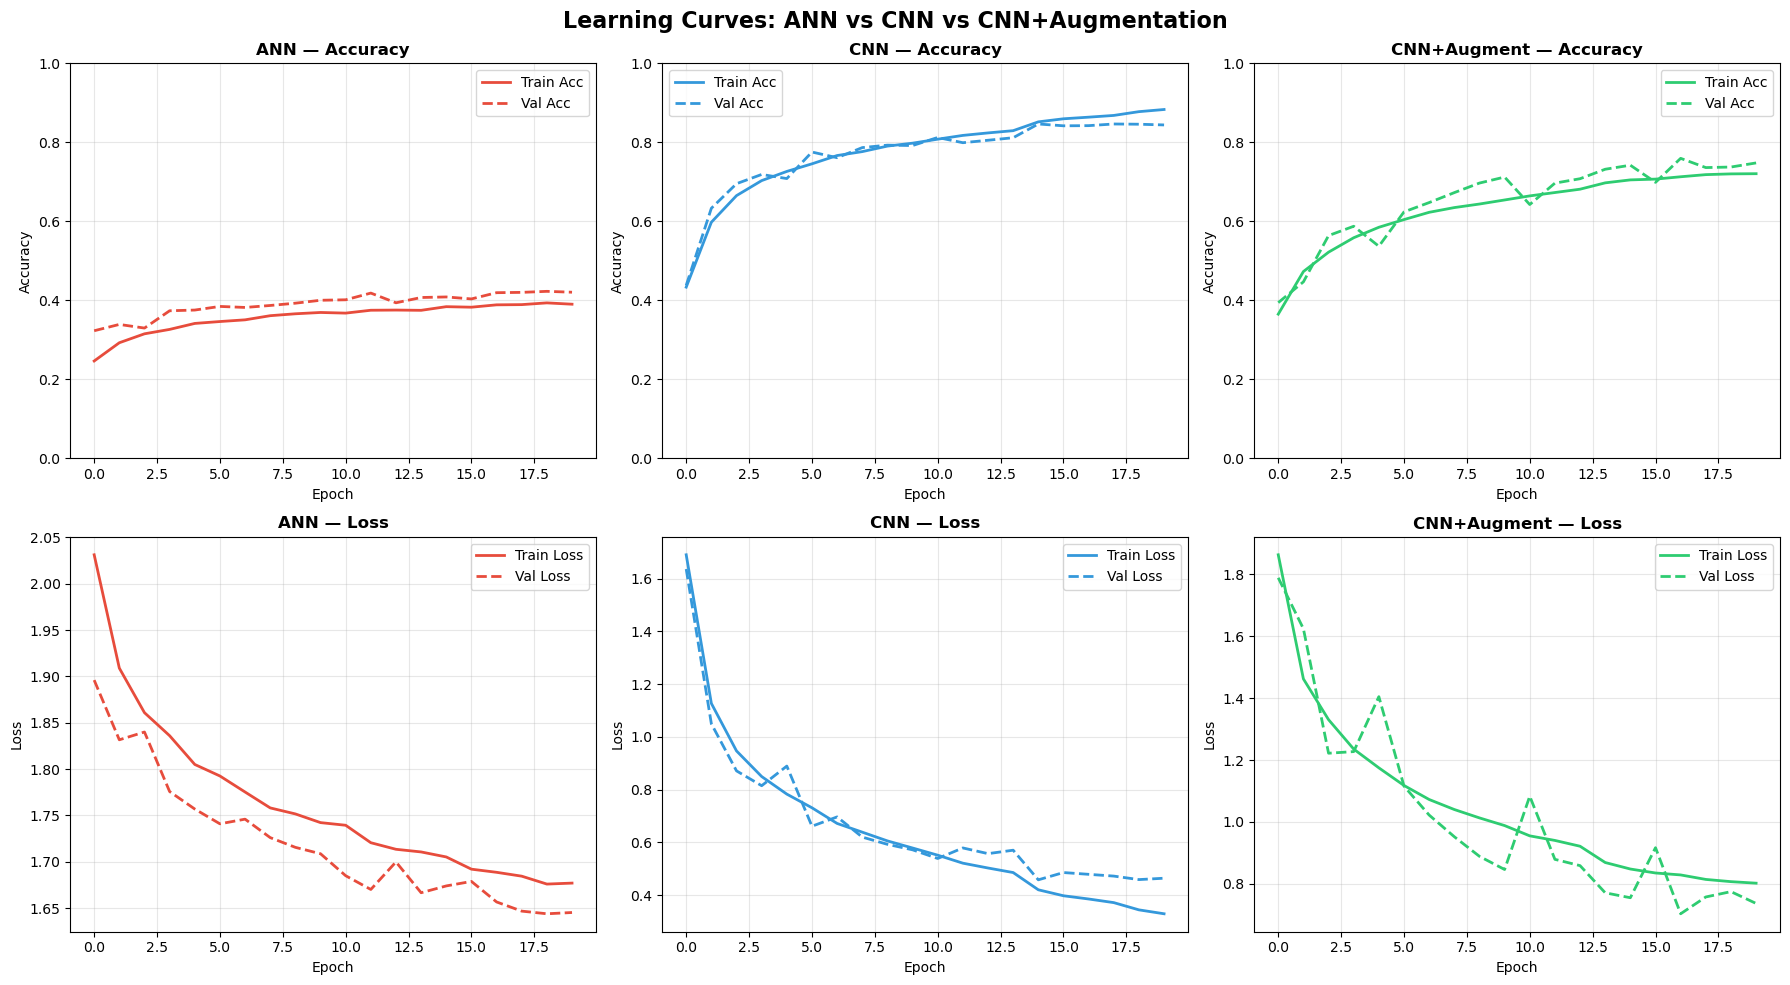

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Learning Curves: ANN vs CNN vs CNN+Augmentation', fontsize=16, fontweight='bold')

models_info = [
    ('ANN',            ann_history,  '#e74c3c'),
    ('CNN',            cnn_history,  '#3498db'),
    ('CNN+Augment',    aug_history,  '#2ecc71'),
]

for col, (name, hist, color) in enumerate(models_info):
    # Accuracy subplot
    ax_acc = axes[0][col]
    ax_acc.plot(hist.history['accuracy'],     label='Train Acc',  color=color, linewidth=2)
    ax_acc.plot(hist.history['val_accuracy'], label='Val Acc',    color=color, linewidth=2, linestyle='--')
    ax_acc.set_title(f'{name} — Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim([0, 1])

    # Loss subplot
    ax_loss = axes[1][col]
    ax_loss.plot(hist.history['loss'],     label='Train Loss', color=color, linewidth=2)
    ax_loss.plot(hist.history['val_loss'], label='Val Loss',   color=color, linewidth=2, linestyle='--')
    ax_loss.set_title(f'{name} — Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

plt.tight_layout()
plt.show()

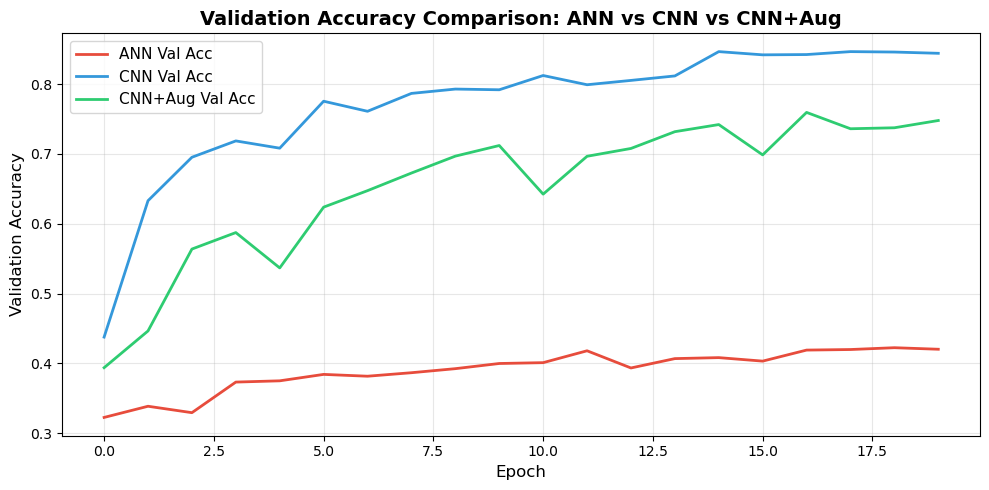

In [ ]:
# ── Overlay Validation Accuracy — All Models ──────────────────────
plt.figure(figsize=(10, 5))
plt.plot(ann_history.history['val_accuracy'],  label='ANN Val Acc',         color='#e74c3c', linewidth=2)
plt.plot(cnn_history.history['val_accuracy'],  label='CNN Val Acc',         color='#3498db', linewidth=2)
plt.plot(aug_history.history['val_accuracy'],  label='CNN+Aug Val Acc',     color='#2ecc71', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Validation Accuracy Comparison: ANN vs CNN vs CNN+Aug', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Per-Class Accuracy Analysis (CNN) ────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_cnn = np.argmax(cnn_model.predict(x_test_norm, verbose=0), axis=1)
y_true = y_test.flatten()

print("CNN Per-Class Classification Report:")
print(classification_report(y_true, y_pred_cnn, target_names=class_names))

CNN Per-Class Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.82      0.85      1000
  automobile       0.93      0.92      0.92      1000
        bird       0.80      0.72      0.76      1000
         cat       0.76      0.61      0.68      1000
        deer       0.79      0.83      0.81      1000
         dog       0.74      0.80      0.77      1000
        frog       0.79      0.93      0.86      1000
       horse       0.86      0.88      0.87      1000
        ship       0.89      0.92      0.90      1000
       truck       0.89      0.91      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



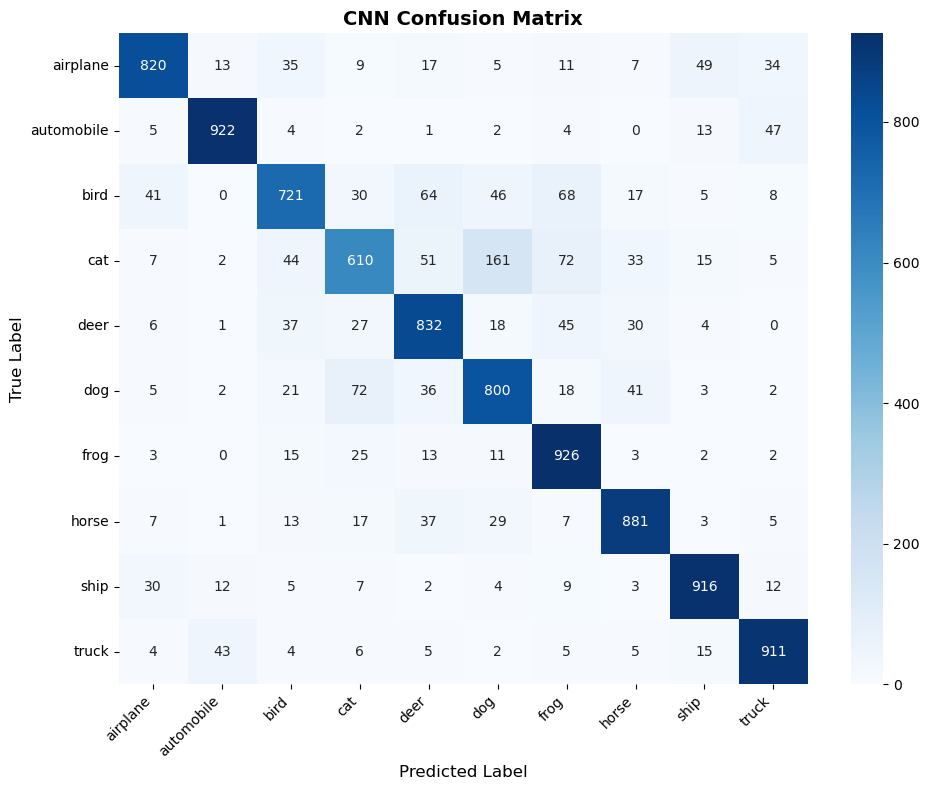


Diagonal = Correct predictions | Off-diagonal = Misclassifications


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('CNN Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nDiagonal = Correct predictions | Off-diagonal = Misclassifications")

In [ ]:
# ── Final Summary Table ───────────────────────────────────────────
ann_params  = ann_model.count_params()
cnn_params  = cnn_model.count_params()
aug_params  = aug_cnn_model.count_params()

ann_epochs_trained  = len(ann_history.history['loss'])
cnn_epochs_trained  = len(cnn_history.history['loss'])
aug_epochs_trained  = len(aug_history.history['loss'])

comparison = pd.DataFrame({
    'Model'           : ['ANN', 'CNN', 'CNN + Augmentation'],
    'Architecture'    : ['Dense only', 'Conv + Pool + Dense', 'Conv + Pool + Augment + Dense'],
    'Parameters'      : [f'{ann_params:,}', f'{cnn_params:,}', f'{aug_params:,}'],
    'Epochs Trained'  : [ann_epochs_trained, cnn_epochs_trained, aug_epochs_trained],
    'Test Loss'       : [round(ann_test_loss, 4), round(cnn_test_loss, 4), round(aug_test_loss, 4)],
    'Test Accuracy %' : [round(ann_test_acc*100, 2), round(cnn_test_acc*100, 2), round(aug_test_acc*100, 2)]
})

print("\n" + "="*80)
print("FINAL COMPARISON TABLE")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

best_model = comparison.loc[comparison['Test Accuracy %'].idxmax(), 'Model']
best_acc   = comparison['Test Accuracy %'].max()
print(f"\n✅ Best performing model: {best_model} with {best_acc:.2f}% test accuracy")


FINAL COMPARISON TABLE
             Model                  Architecture Parameters  Epochs Trained  Test Loss  Test Accuracy %
               ANN                    Dense only  1,738,890              20     1.6328            42.19
               CNN           Conv + Pool + Dense    668,458              20     0.4968            83.39
CNN + Augmentation Conv + Pool + Augment + Dense    668,458              20     0.7443            74.58

✅ Best performing model: CNN with 83.39% test accuracy


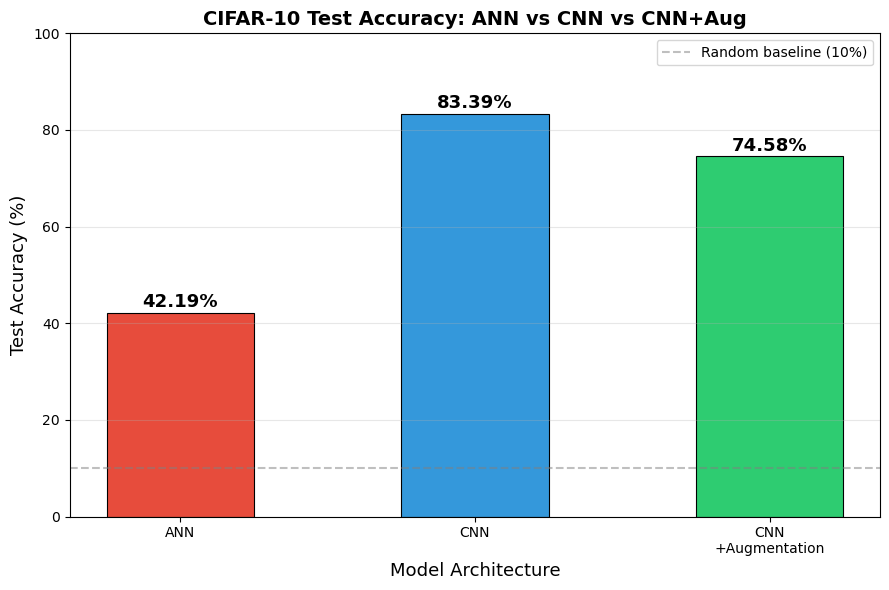

In [ ]:
# ── Bar Chart: Model Accuracy Comparison ─────────────────────────
models_list  = ['ANN', 'CNN', 'CNN\n+Augmentation']
accuracies   = [ann_test_acc*100, cnn_test_acc*100, aug_test_acc*100]
colors       = ['#e74c3c', '#3498db', '#2ecc71']

plt.figure(figsize=(9, 6))
bars = plt.bar(models_list, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.xlabel('Model Architecture', fontsize=13)
plt.ylabel('Test Accuracy (%)', fontsize=13)
plt.title('CIFAR-10 Test Accuracy: ANN vs CNN vs CNN+Aug', fontsize=14, fontweight='bold')
plt.ylim([0, 100])
plt.axhline(y=10, color='gray', linestyle='--', alpha=0.5, label='Random baseline (10%)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

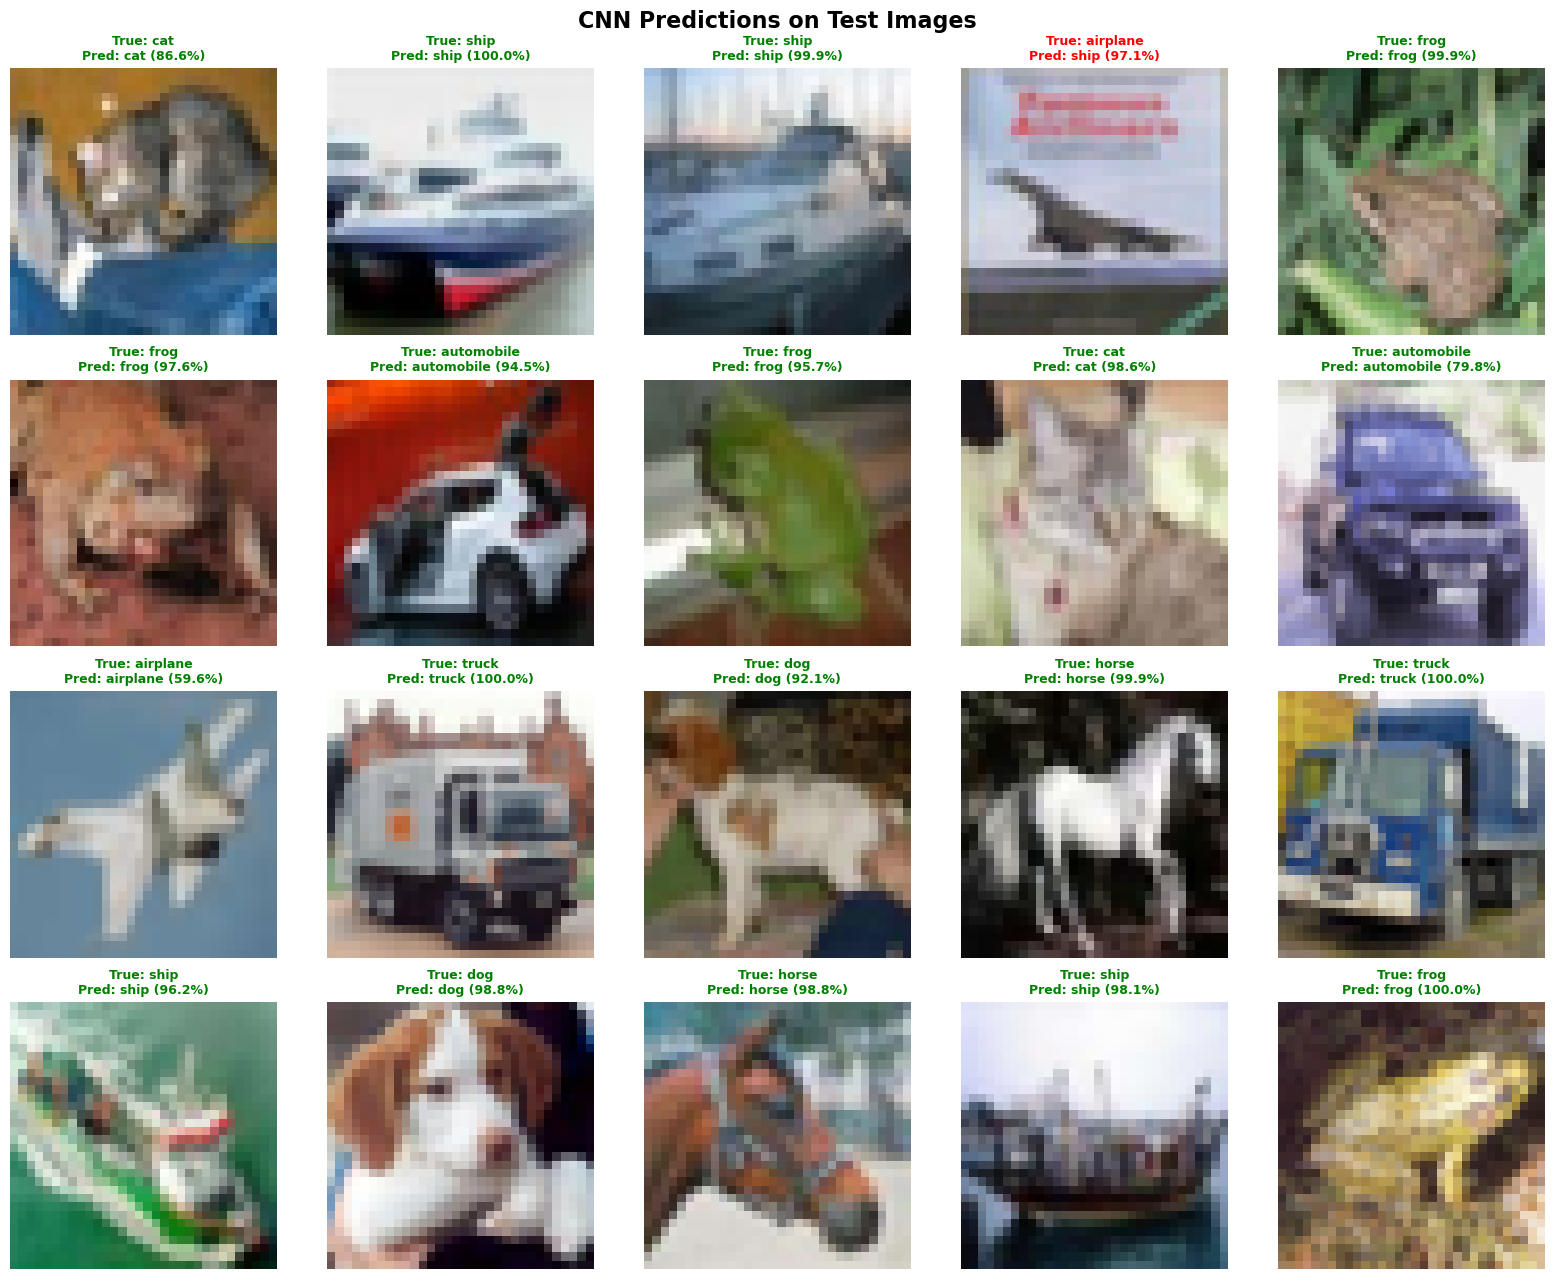

Green title = Correct prediction | Red title = Wrong prediction


In [ ]:
# ── Visualize CNN Predictions ─────────────────────────────────────
probs = cnn_model.predict(x_test_norm[:20], verbose=0)
preds = np.argmax(probs, axis=1)

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('CNN Predictions on Test Images', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i])
    true_label = class_names[y_test[i][0]]
    pred_label = class_names[preds[i]]
    confidence = probs[i][preds[i]] * 100
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                 color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Green title = Correct prediction | Red title = Wrong prediction")